Figure S1: PEER factor residualization’s effect on correlation. A Correlation matrix of gene expression in chromosome 17 for sun exposed skin; Spearman correlation before (lower) and after (upper) residualization with 60 PEER factors. Correlations with Bernoulli significant p-value are shown. B CDF of pairwise gene distances of genes with significantly correlated gene expression profiles after residualization with 0, 15, 30, 45, and 60 PEER factors.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy.stats import spearmanr
import pyranges as pr



from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 

%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# load in clusters
clusters = load_across_tissues(config, load_clusters_annotated)

In [4]:
# example chr to do 
my_tissue_id = 'Skin_Sun_Exposed_Lower_leg'
chr_num = 17
# load in covatiates
covariates_df = pd.read_csv('{}/{}/{}.v8.covariates.txt'.format(prefix, config['covariates_dir'], my_tissue_id), sep='\t', index_col=0).T
base_covariates = covariates_df[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'pcr', 'platform', 'sex']]
peer_covariates = covariates_df[[f'InferredCov{i}' for i in range(1,61,1)]]

# load in expression
expression_df = load_expression(config, my_tissue_id)
expression_df = expression_df.set_index('gene_id')[covariates_df.index]


# load in the gene information (for gene-gene distances)
gid_gencode = load_gencode()
gid_gencode_tissue = gid_gencode.loc[expression_df.index]
# get the genes to plot
selected_chr_gene_ids = gid_gencode_tissue[gid_gencode_tissue['chr'] == f'chr{chr_num}'].index.values
selected_chr_gene_names = gid_gencode_tissue[gid_gencode_tissue['chr'] == f'chr{chr_num}']['gene_name']

def get_total_pairs(gid_gencode_tissue):
    # calculate total number of pairs considered for bonferroni correction
    total_pairs = 0
    max_cluster_size=50
    for i in np.arange(1,23,1):
        chr_gene_ids = gid_gencode_tissue[gid_gencode_tissue['chr'] == f'chr{i}'].index.values
        upper_corner_idxs = np.triu(np.ones(len(chr_gene_ids)), k=1)
        excluded_cluster_size_idxs = np.triu(np.ones(len(chr_gene_ids)), k=max_cluster_size)
        total_pairs += upper_corner_idxs.sum()  - excluded_cluster_size_idxs.sum()
    return total_pairs

total_pairs = get_total_pairs(gid_gencode_tissue)

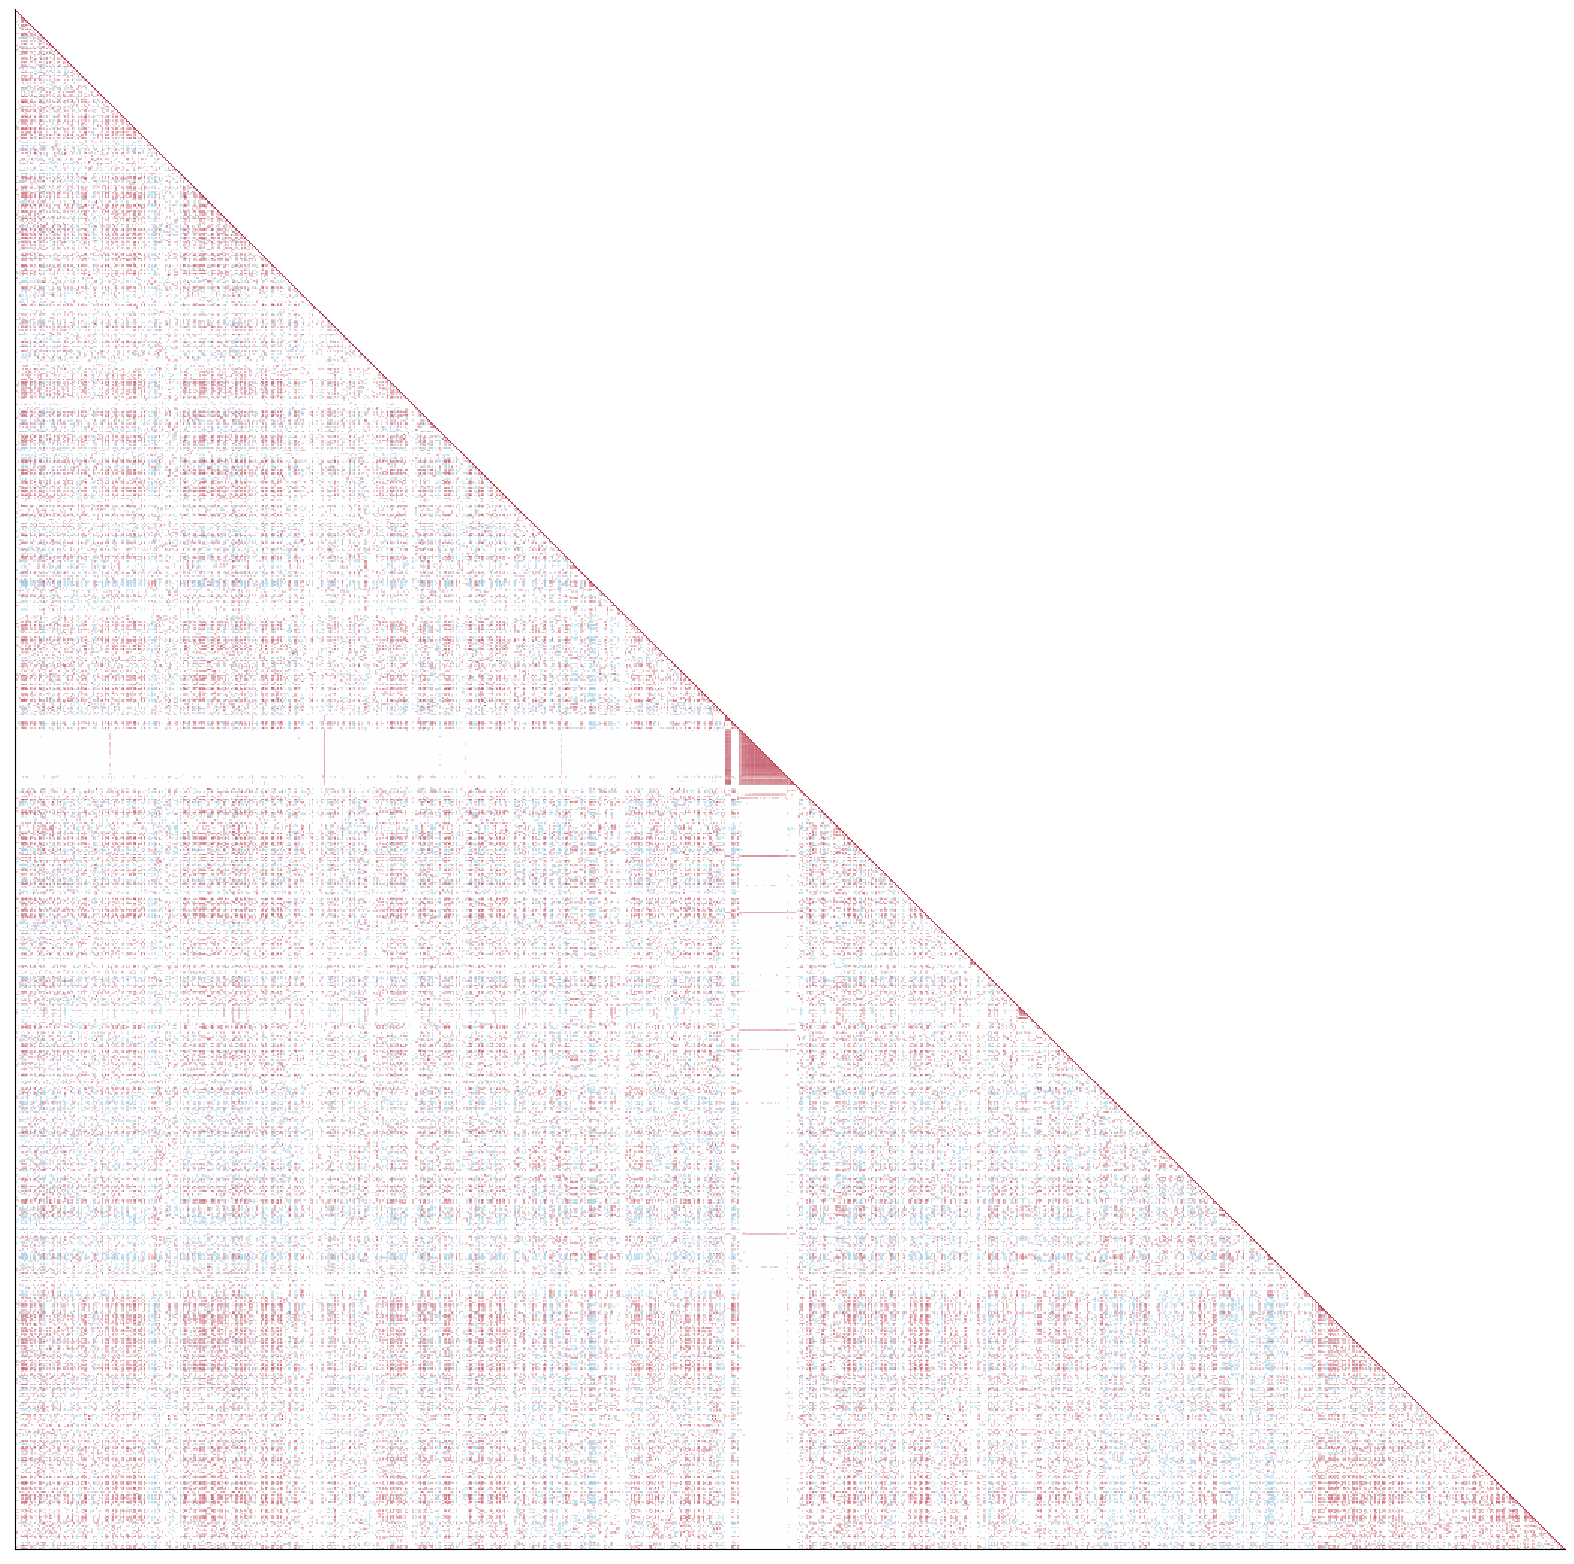

In [ ]:
init_corr, init_pvalue = spearmanr(expression_df.loc[selected_chr_gene_ids], axis=1)

# mask non-sig corrs
init_corr_masked = init_corr.copy()
init_corr_masked[init_pvalue >= (.05/total_pairs)] = 0
init_corr_masked = pd.DataFrame(init_corr_masked, index=selected_chr_gene_names, columns=selected_chr_gene_names)

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(init_corr_masked, mask=np.triu(np.ones_like(init_corr), k=1), cmap=corr_cmap, vmin=-1, vmax=1, ax=ax, cbar_kws={'label':'Spearman Corrleation', 'pad':0}, xticklabels=False, yticklabels=False, cbar=False)

ax.spines[['bottom', 'left']].set_visible(True)
ax.set_xlabel('')
ax.set_ylabel('')
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s1_a.1.pdf", transparent=True)
plt.show()

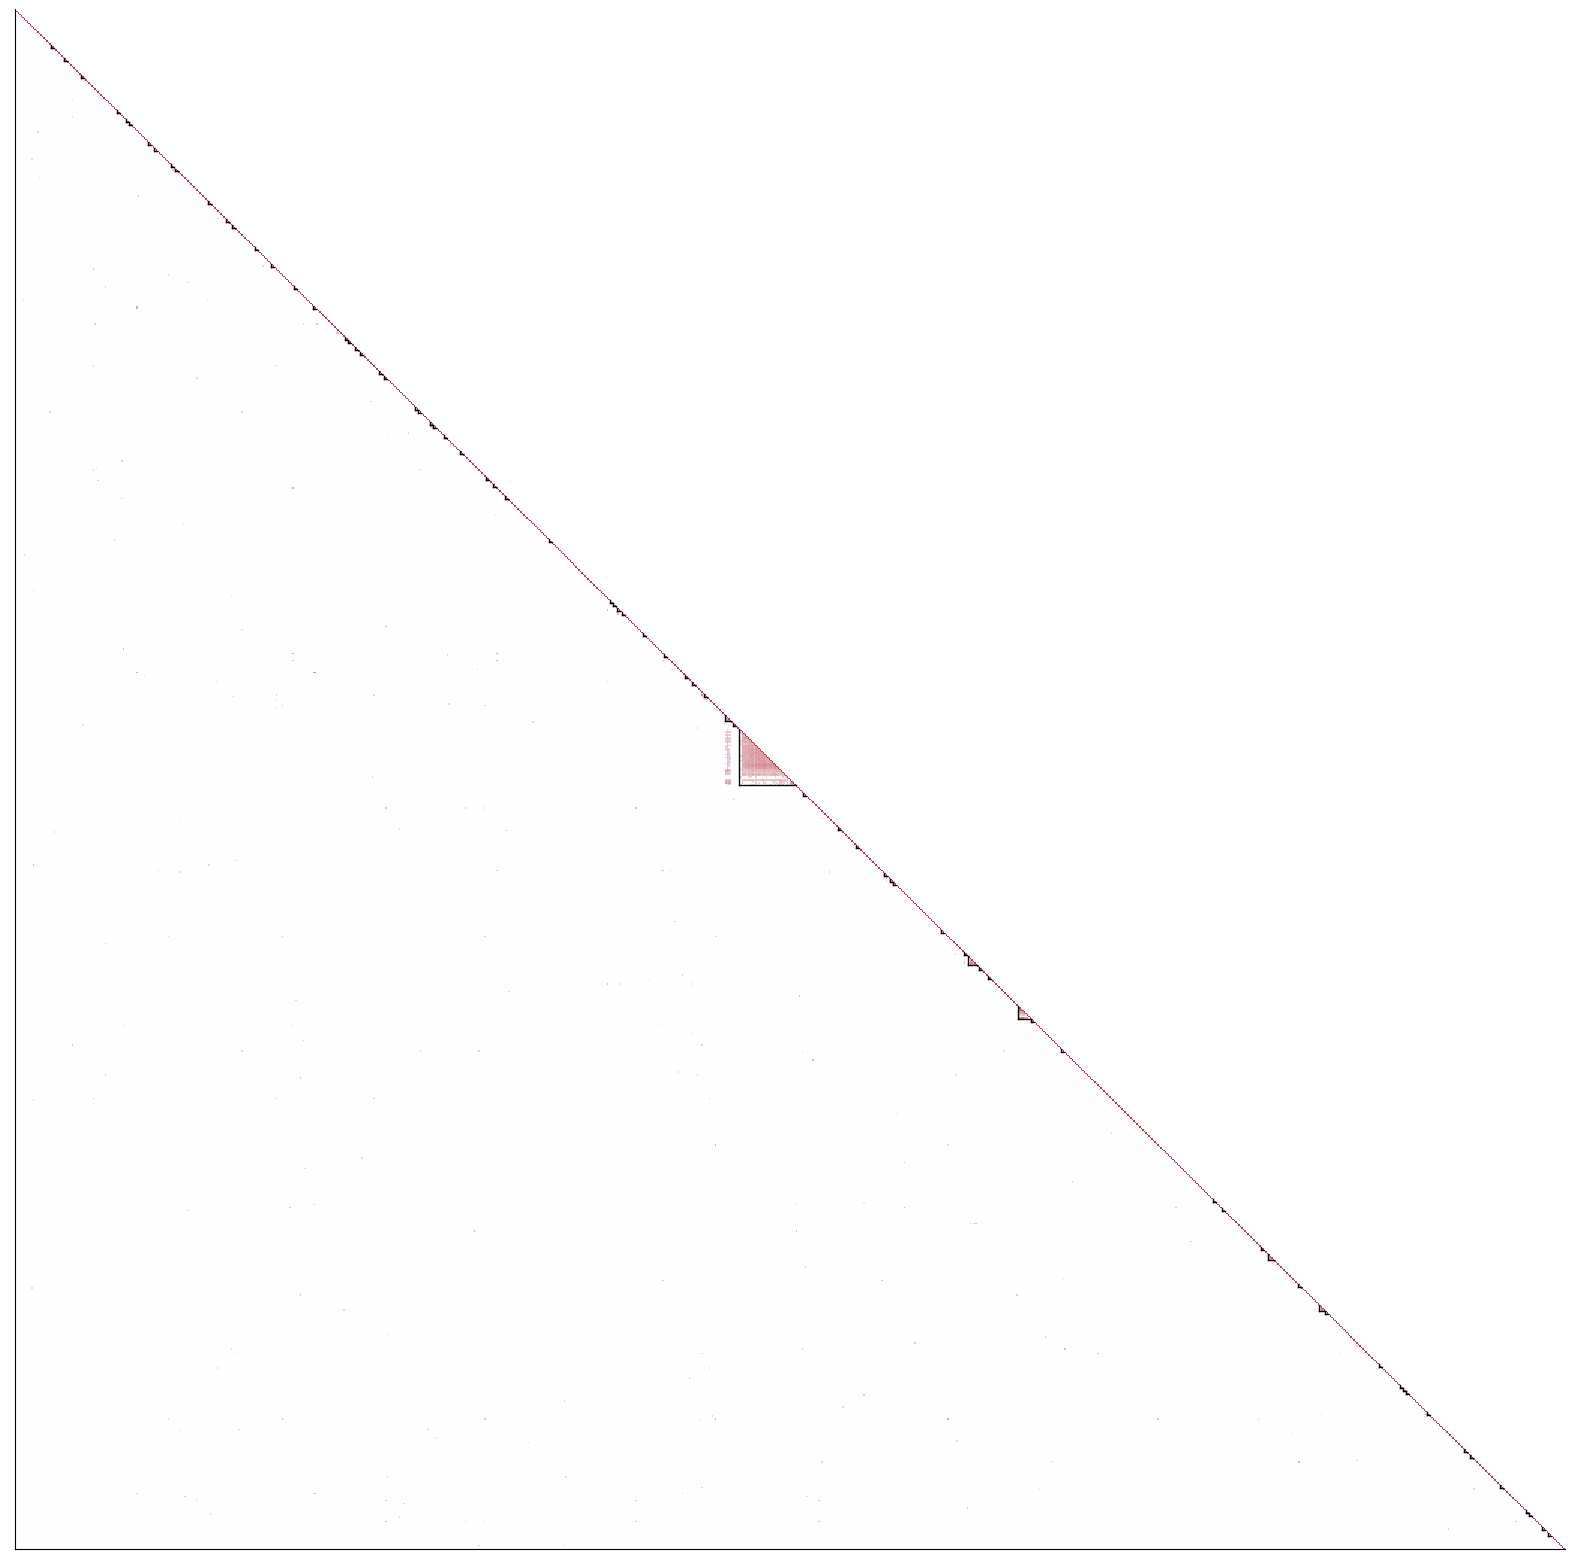

In [ ]:
# function to residualize expression based on two covariate dfs
def two_part_residualize(expression_df, base_covariates_df, additional_covariates_df):
    full_covariates = pd.concat([base_covariates_df, additional_covariates_df], axis=1)
    # residulize the expression 
    residal_exp = calculate_residual(expression_df[full_covariates.index], full_covariates, center=True)
    residal_exp = pd.DataFrame(residal_exp, columns=full_covariates.index, index=expression_df.index)
    return residal_exp


# corr with all 60 peers removed
peer_residual_exp = two_part_residualize(expression_df, base_covariates, peer_covariates)
corrected_corr, corrected_pvalue = spearmanr(peer_residual_exp.loc[selected_chr_gene_ids], axis=1)

# mask non-sig corrs
corrected_corr_masked = corrected_corr.copy()
corrected_corr_masked[corrected_pvalue >= (.05/total_pairs)] = 0
corrected_corr_masked = pd.DataFrame(corrected_corr_masked, index=selected_chr_gene_names, columns=selected_chr_gene_names)

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corrected_corr_masked, mask=np.triu(np.ones_like(corrected_corr), k=1), cmap=corr_cmap, vmin=-1, vmax=1, ax=ax, cbar_kws={'label':'Spearman Corrleation', 'pad':0}, xticklabels=False, yticklabels=False, cbar=False)

# add in clusters
for idx, cluster in clusters[(clusters['Chromosome']==chr_num)&(clusters['tissue_id']==my_tissue_id)].iterrows():
    cluster_idxs = np.concatenate([np.where(selected_chr_gene_ids==cluster['Transcripts'].split(',')[i])[0] for i in range(cluster['N_genes'])])
    if len(cluster_idxs) > 0:
        # Calculate rectangle properties
        x = cluster_idxs[0]
        y = cluster_idxs[0]
        width = np.ptp(cluster_idxs) + 1
        height = np.ptp(cluster_idxs) + 1
        ax.plot([x, x + width], [y + height, y + height], color='k', linewidth=1)
        ax.plot([x, x], [y, y + height], color='k', linewidth=1)
    
ax.spines[['bottom', 'left']].set_visible(True)
ax.set_xlabel('')
ax.set_ylabel('')
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s1_a.2.pdf", transparent=True)
plt.show()

In [27]:
full_genocde = pr.read_gtf("/home/klawren/oak/pcqtls/data/references/gencode.v26.annotation.gtf.gz", as_df=True)
genes = full_genocde[full_genocde['Feature'] == 'gene']
genes['tss_start'] = np.where(genes['Strand'] == '+', genes['Start'], genes['End'])
strand_dict = genes.set_index('gene_id')['Strand'].to_dict()
tss_dict = genes.set_index('gene_id')['tss_start'].to_dict()

/local/scratch/klawren/slrmtmp.48343185/ipykernel_50921/4174605719.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes['tss_start'] = np.where(genes['Strand'] == '+', genes['Start'], genes['End'])


In [ ]:
# Calculate distances and add to the significant_corr DataFrame
def calculate_distance(row):
    gene1 = row['gene_id_1']
    gene2 = row['gene_id_2']
    tss1 = tss_dict.get(gene1)
    tss2 = tss_dict.get(gene2)
    return abs(tss1 - tss2) 

def get_corr_pairs(expression_df, gene_ids, total_pairs):
    corr, pvalue = spearmanr(expression_df.loc[gene_ids], axis=1)
    # mask non-sig corrs
    corr_masked = corr.copy()
    corr_masked[pvalue >= (.05/total_pairs)] = 0
    corr_masked = pd.DataFrame(corr_masked, index=selected_chr_gene_ids, columns=selected_chr_gene_ids)
    corr_pairs = corr_masked.stack().reset_index()
    corr_pairs.columns = ['gene_id_1', 'gene_id_2', 'corr']
    corr_pairs = corr_pairs[corr_pairs['gene_id_1'] !=corr_pairs['gene_id_2']]
    # only keep signifignat ones
    sig_corr_pairs = corr_pairs[corr_pairs['corr']!=0].copy()
    
    # add tss to tss distance
    sig_corr_pairs.loc[:, 'distance'] = sig_corr_pairs.apply(calculate_distance, axis=1)
    return sig_corr_pairs

In [ ]:
my_tissue_id = 'Cells_Cultured_fibroblasts'

# load in covatiates
covariates_df = pd.read_csv('{}/{}/{}.v8.covariates.txt'.format(prefix, config['covariates_dir'], my_tissue_id), sep='\t', index_col=0).T
base_covariates = covariates_df[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'pcr', 'platform', 'sex']]
peer_covariates = covariates_df[[f'InferredCov{i}' for i in range(1,61,1)]]

# load in expression
expression_df = load_expression(config, my_tissue_id)
expression_df = expression_df.set_index('gene_id')[covariates_df.index]

# get the genes on this chr only
gid_gencode_tissue = gid_gencode.loc[expression_df.index]

chr_corr_pairs_list=[]
for chr_num in tqdm(range(1, 23)):
    selected_chr_gene_ids = gid_gencode_tissue[gid_gencode_tissue['chr'] == f'chr{chr_num}'].index.values
    for num_peers in [0, 15, 30, 45, 60]:
        residual_exp = two_part_residualize(expression_df, base_covariates, peer_covariates.iloc[:, :num_peers])
        chr_corr_pairs_list.append(get_corr_pairs(residual_exp, selected_chr_gene_ids, total_pairs))

chr_corr_pairs = pd.concat(chr_corr_pairs_list, keys=np.tile([0, 15, 30, 45, 60], 22), names=['num_peer'])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [02:05<00:00,  5.69s/it]


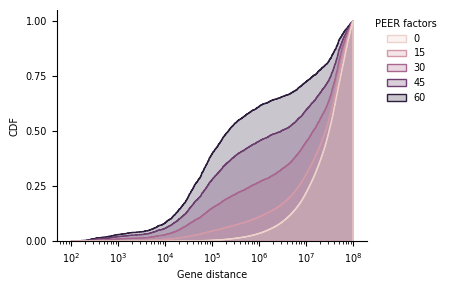

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

sns.histplot(data=chr_corr_pairs, x='distance', hue='num_peer', stat='density', cumulative=True, bins=np.arange(2, 8, .01), element='step', log_scale=True, common_norm=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Gene distance')
ax.set_ylabel('CDF')
ax.set_yticks([0, .25, .5, .75, 1])

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), frameon=False, title='PEER factors')
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s1_b.pdf", transparent=True)
plt.show()

In [ ]:
# numbers for the writing
print(chr_corr_pairs.loc[0]['distance'].median()/1e6)
print(chr_corr_pairs.loc[60]['distance'].median()/1e3)

40.017897
286.234
